In [85]:
import sympy as sp

x,y,z,u,v,w,e,k = sp.symbols('x y z u v w e k')

f = x*(x-z)*y+1
fs = f.subs([(z, v), (x, u+v**e), (y, w+v**k)])
fs.expand()
fs.subs([(e,0), (k,1)]).expand()
# Check which e, k work

u**2*v + u**2*w - u*v**2 - u*v*w + 2*u*v + 2*u*w - v**2 - v*w + v + w + 1

In [86]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def plot_implicit(fn, bbox=(-5,5), cmap=cm.viridis):
    xmin, xmax = bbox
    ymin, ymax = bbox
    zmin, zmax = bbox

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    A = np.linspace(xmin, xmax, 200)
    B = np.linspace(xmin, xmax, 40)
    A1, A2 = np.meshgrid(A, A)
    norm = plt.Normalize(vmin=xmin, vmax=xmax)

    for z in B:
        X, Y = A1, A2
        Z = fn(X, Y, z)

        ax.contour(
            X, Y, Z + z,
            levels=[z],
            zdir='z',
            colors=[cmap(norm(z))],
            alpha=0.7
        )
    for y in B:
        X, Z = A1, A2
        Y = fn(X, y, Z)

        ax.contour(
            X, Y + y, Z,
            levels=[y],
            zdir='y',
            colors=[cmap(norm(y))],
            alpha=0.5
        )
    for x in B:
        Y, Z = A1, A2
        X = fn(x, Y, Z)

        ax.contour(
            X + x, Y, Z,
            levels=[x],
            zdir='x',
            colors=[cmap(norm(x))],
            alpha=0.5
        )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.show()

<IPython.core.display.Javascript object>


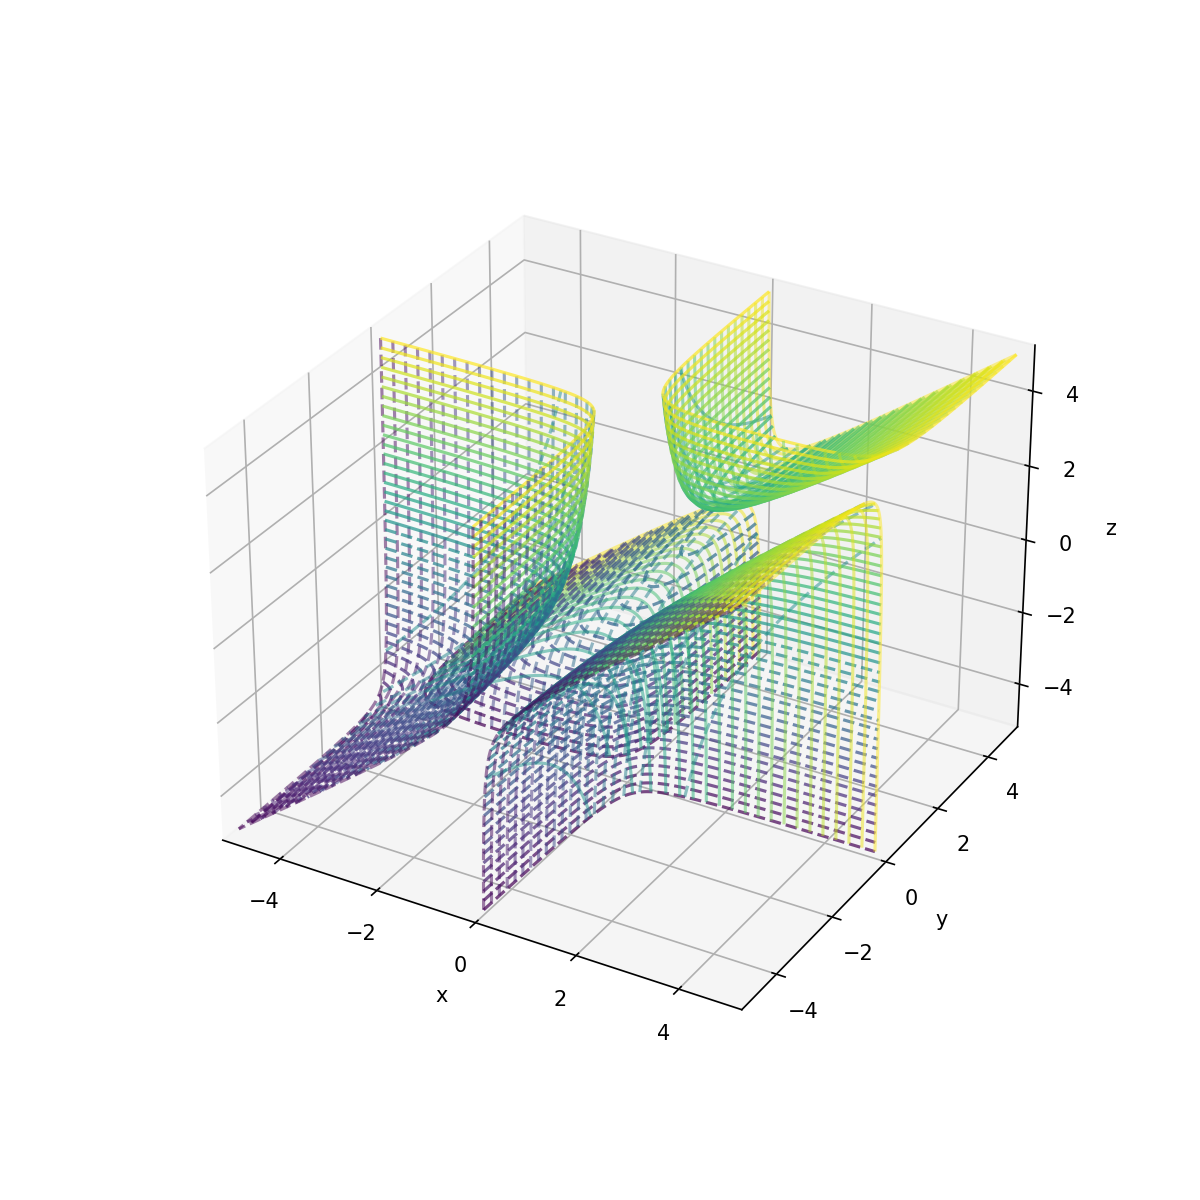

C:\Users\Bastian\AppData\Local\Temp\ipykernel_19980\1992916613.py:33: UserWarning: No contour levels were found within the data range.
  ax.contour(


In [87]:
%matplotlib notebook 
def f(x,y,z):
    return (x+z**2)*(y+z)*(x+z**2-z)+1

def f2(x,y,z):
    return x*(x-z)*y+1
plot_implicit(f2)

In [93]:
# Use vispy to create more responsive interactive plots

%gui qt
import numpy as np
import vispy
from vispy import app, scene
from vispy.scene.visuals import Mesh
from vispy.scene import TurntableCamera
from skimage import measure


def f(x, y, z):
    return (x + z**2)*(y + z)*(x + z**2 - z) + 1

def f2(x, y, z):
    return x*(x - z)*y + 1

# Change bounds to show more of the plot
def generate_volume(fn, bounds=(-4, 4), resolution=200):
    xmin, xmax = bounds
    grid = np.linspace(xmin, xmax, resolution)
    X, Y, Z = np.meshgrid(grid, grid, grid, indexing='ij')
    V = fn(X, Y, Z)
    return V, grid

def compute_isosurface(V, grid):
    # marching cubes
    verts, faces, normals, values = measure.marching_cubes(V, level=0)
    scale = (grid[-1] - grid[0]) / (len(grid) - 1)
    verts = verts * scale + grid[0]
    return verts, faces



def plot_implicit_vispy(fn):
    V, grid = generate_volume(fn)
    verts, faces = compute_isosurface(V, grid)
    canvas = scene.SceneCanvas(keys='interactive', show=True)
    view = canvas.central_widget.add_view()

    z_vals = verts[:, 2]
    z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min())

    colors = np.zeros((len(verts), 4))
    colors[:, 0] = z_norm # red
    colors[:, 1] = 0.03 # green
    colors[:, 2] = 2 - z_norm # blue
    colors[:, 3] = 1.0 # alpha
    print(len(verts))
    mesh = scene.visuals.Mesh(
    vertices=verts,
    faces=faces,
    vertex_colors=colors,
    shading='smooth'
    )
    view.add(mesh)
    view.camera = TurntableCamera(fov=60, distance=10)
    axis = scene.visuals.XYZAxis(parent=view.scene)
    app.run()



In [94]:
# Additionally, possibility to save image
def plot_implicit_vispy(fn):
    V, grid = generate_volume(fn)
    verts, faces = compute_isosurface(V, grid)
    canvas = scene.SceneCanvas(keys='interactive', show=True)
    view = canvas.central_widget.add_view()
    z_vals = verts[:, 2]
    z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min())

    colors = np.zeros((len(verts), 4))
    colors[:, 0] = 2*z_norm # red
    colors[:, 1] = 0.0 # green
    colors[:, 2] = 1 - z_norm # blue
    colors[:, 3] = 1.0 # alpha

    print(len(verts))
    mesh = scene.visuals.Mesh(
    vertices=verts,
    faces=faces,
    vertex_colors=colors,
    shading='smooth'
    )
    view.add(mesh)
    view.camera = TurntableCamera(fov=60, distance=10)
    ax = scene.visuals.XYZAxis(parent=view.scene)
    ax.visible = False
    @canvas.events.key_press.connect
    def on_key(event):
        if event.key == 'S':
            canvas.bgcolor = 'white'
            img = canvas.render()
            #img = canvas.render(size=(2000, 2000))
            from imageio import imwrite
            imwrite("surface.png", img)
            print("Done")

    app.run()
plot_implicit_vispy(f2)

153982


In [97]:
def plot_implicit_vispy_video(fn, output="rotation.mp4", n_frames=180):
    V, grid = generate_volume(fn)
    verts, faces = compute_isosurface(V, grid)
    canvas = scene.SceneCanvas(keys='interactive', show=True)
    view = canvas.central_widget.add_view()
    z_vals = verts[:, 2]
    z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min())

    colors = np.zeros((len(verts), 4))
    colors[:, 0] = 2 * z_norm # red
    colors[:, 1] = 0.0 # green
    colors[:, 2] = 1 - z_norm # blue
    colors[:, 3] = 1.0 # alpha

    mesh = scene.visuals.Mesh(
        vertices=verts,
        faces=faces,
        vertex_colors=colors,
        shading='smooth'
    )
    view.add(mesh)
    cam = TurntableCamera(fov=60, distance=10)
    view.camera = cam
    ax = scene.visuals.XYZAxis(parent=view.scene)
    ax.visible = False

    frames = []
    for i in range(n_frames):
        cam.azimuth += 1.0

        canvas.update()
        canvas.app.process_events()
        img = canvas.render()
        frames.append(img)

    print("Saving video...")
    imageio.mimsave(output, frames, fps=30)
    print(f"Video saved as {output}")

    app.quit()


plot_implicit_vispy_video(f2)


Saving video...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as rotation.mp4


Defaulting to user installation because normal site-packages is not writeable
     --------------------------------------- 31.2/31.2 MB 25.2 MB/s eta 0:00:00
